In [1]:
from src import clustering, graph_utils, plotting
import spatialdata as sd
import os 
# sdata = sd.read_zarr("zarr/debug_dataset.zarr")
sdata = sd.read_zarr("zarr/Brain_Human.zarr")
adata = sdata.tables["table"]

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


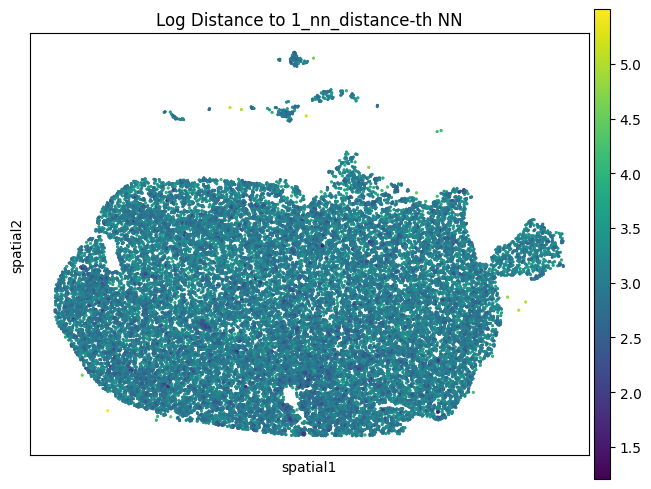

In [2]:
K = 1
graph_utils.get_distances(adata, k=1, log=True)
plotting.plot_knn_distance(adata, distance_key=f"{K}_nn_distance")

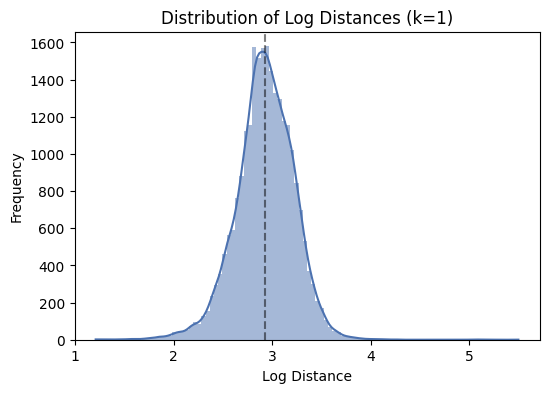

In [3]:
plotting.plot_knn_histogram(adata, k=1, bins=100)

In [4]:
results = clustering.fit_gmm(adata, distance_key="1_nn_distance", k_range=range(1,10))
# Some functionality missing like multiple inits

Fitted GMM with k=1
Fitted GMM with k=2
Fitted GMM with k=3
Fitted GMM with k=4
Fitted GMM with k=5
Fitted GMM with k=6
Fitted GMM with k=7
Fitted GMM with k=8
Fitted GMM with k=9


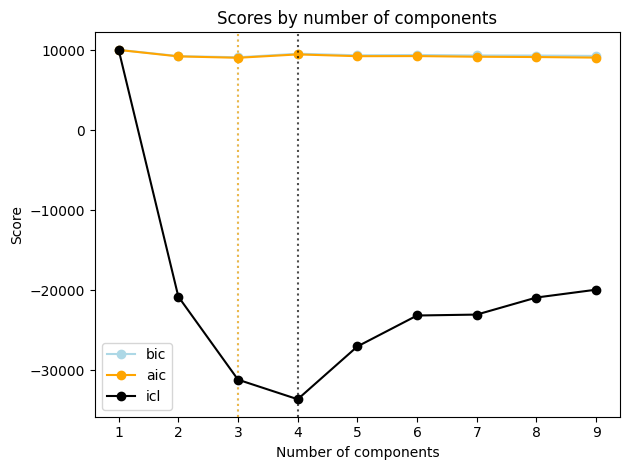

In [5]:
plotting.plot_scores(results)

In [6]:
best_model_icl = clustering.choose_component(results, criterion="icl", delta_bic_threshold=10.0)
best_model_bic = clustering.choose_component(results, criterion="bic", delta_bic_threshold=10.0)
best_model_aic = clustering.choose_component(results, criterion="aic", delta_bic_threshold=10.0)

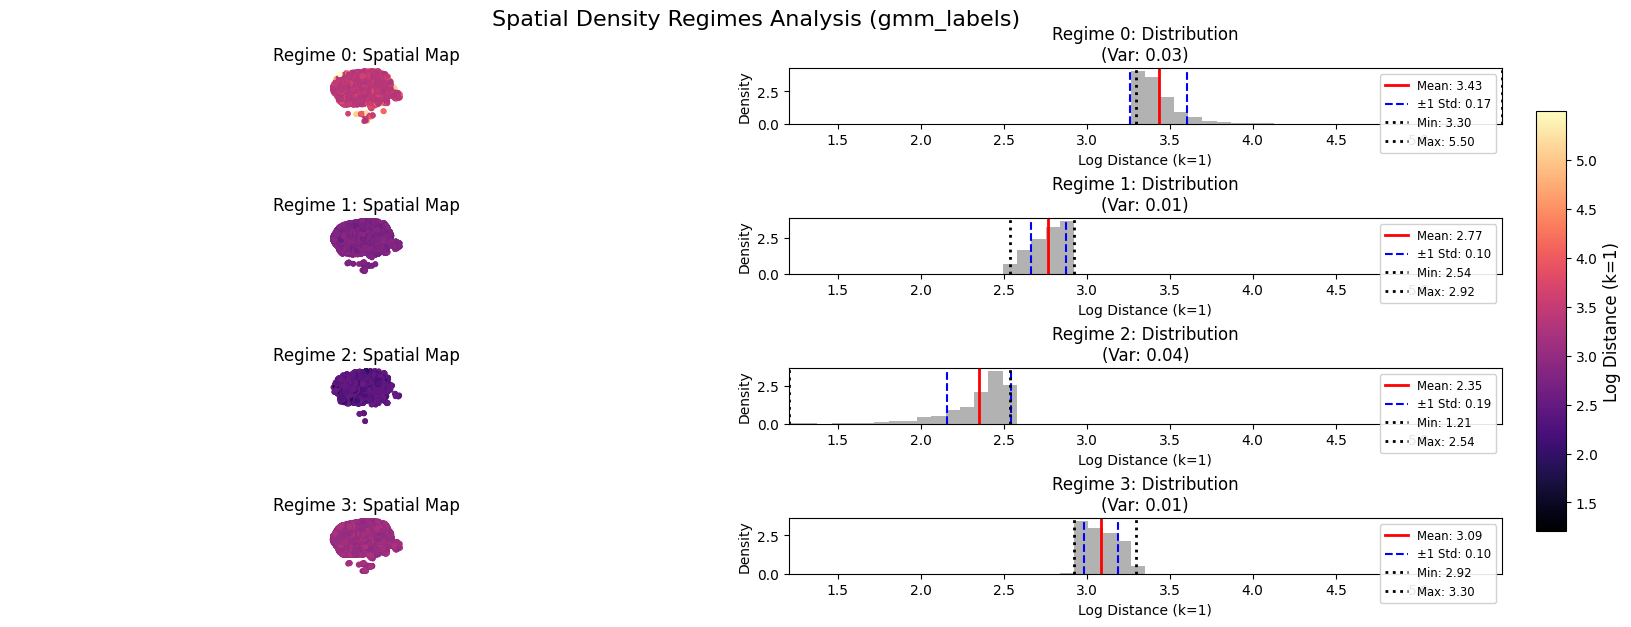

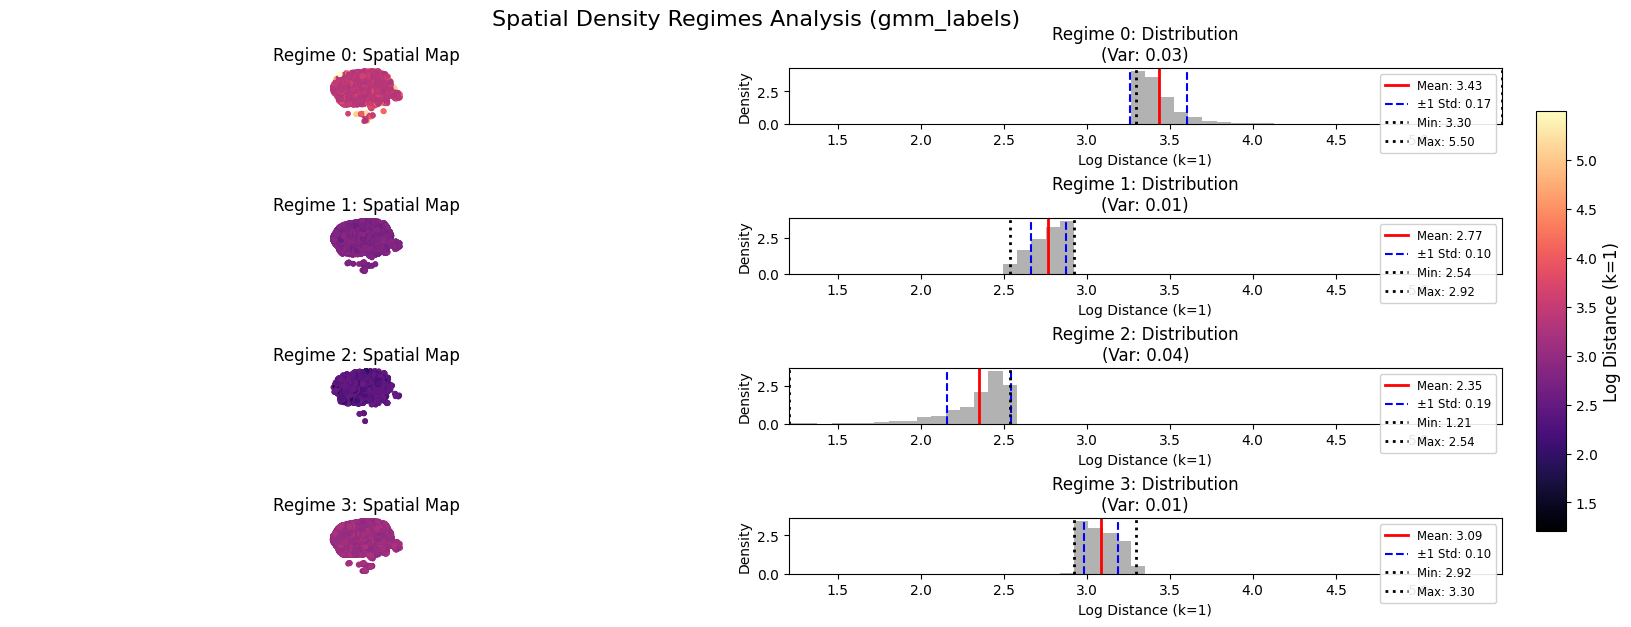

In [7]:
adata.obs["gmm_labels"] = best_model_icl["labels"]
adata.obs["gmm_labels"] = adata.obs["gmm_labels"].astype("category") 
plotting.plot_knn_by_regime(
    adata, 
    labels_key="gmm_labels", 
    k=1,             # Use k=1 distances
    size=10,         # Adjust dot size based on your data density
    cmap="magma",    # 'magma' is often good for density (dark = dense, bright = sparse)
    figsize=(15, 6)  # Force a specific figure size if the auto-calc isn't perfect
)

In [8]:
graph_utils.get_neighbors(adata, type="delaunay")

In [9]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

def plot_pruned_connections(
    adata, 
    gmm_key, 
    basis="spatial", 
    prune_by="label", 
    distance_key=None, 
    n_std=2.0, 
    point_size=5,
    mode="comparison",
    ax=None,
    figsize=(16, 8)
):
    """
    Visualizes graph pruning.
    If prune_by="distance", compares log(spatial_distances) vs log-thresholds.
    """
    
    # --- 1. Data Retrieval ---
    if f"X_{basis}" in adata.obsm:
        coords = adata.obsm[f"X_{basis}"]
    elif basis in adata.obsm:
        coords = adata.obsm[basis]
    else:
        raise KeyError(f"Could not find coordinates in adata.obsm['{basis}']")

    adj_matrix = adata.obsp["spatial_distances"].tocoo()
    sources = adj_matrix.row
    targets = adj_matrix.col
    weights = adj_matrix.data # These are linear distances
    
    # --- 2. Determine Edges to Keep ---
    labels = adata.obs[gmm_key].values

    if prune_by == "label":
        edge_is_kept = labels[sources] == labels[targets]

    elif prune_by == "distance":
        if distance_key is None:
            raise ValueError("Must provide 'distance_key' when prune_by='distance'")
            
        # Stats on LOG values
        stats = adata.obs.groupby(gmm_key, observed=False)[distance_key].agg(['mean', 'std'])
        stats['std'] = stats['std'].fillna(0)
        
        # Calc LOG threshold
        stats['log_threshold'] = stats['mean'] + (n_std * stats['std'])
        
        # Map to cells
        mapping_dict = stats['log_threshold'].to_dict()
        cell_thresholds = adata.obs[gmm_key].map(mapping_dict).astype(float).values
        
        # Log the graph weights
        log_weights = np.log(weights + 1e-12)
        
        # Compare Log Weights vs Log Thresholds
        thresholds_per_edge = cell_thresholds[sources]
        edge_is_kept = log_weights <= thresholds_per_edge
        
    else:
        raise ValueError(f"Unknown pruning strategy: {prune_by}")

    # --- 3. Build Segments ---
    start_points = coords[sources]
    end_points = coords[targets]
    segments = np.stack((start_points, end_points), axis=1)

    kept_segments = segments[edge_is_kept]
    pruned_segments = segments[~edge_is_kept]
    
    n_kept = len(kept_segments)
    n_pruned = len(pruned_segments)

    # --- 4. Plotting ---
    def draw_graph(axis, show_pruned=True, title=""):
        axis.scatter(coords[:, 0], coords[:, 1], c=labels, s=point_size, cmap='tab20', zorder=10)
        
        lc_kept = LineCollection(kept_segments, colors='lightgray', linewidths=0.5, alpha=0.5, zorder=1)
        axis.add_collection(lc_kept)
        
        if show_pruned:
            lc_pruned = LineCollection(pruned_segments, colors='red', linewidths=1.0, alpha=0.8, zorder=5)
            axis.add_collection(lc_pruned)
            
        axis.set_title(title)
        axis.axis('equal')
        axis.axis('off')

    if mode == "comparison":
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        draw_graph(ax1, show_pruned=True, title=f"Candidates (Red)\nPruned: {n_pruned}")
        draw_graph(ax2, show_pruned=False, title=f"Final Graph\nKept: {n_kept}")
        return fig, (ax1, ax2)
    else:
        if ax is None: fig, ax = plt.subplots(figsize=(8, 8))
        show_p = (mode == "highlight")
        draw_graph(ax, show_pruned=show_p, title=f"Graph ({mode})")
        return ax

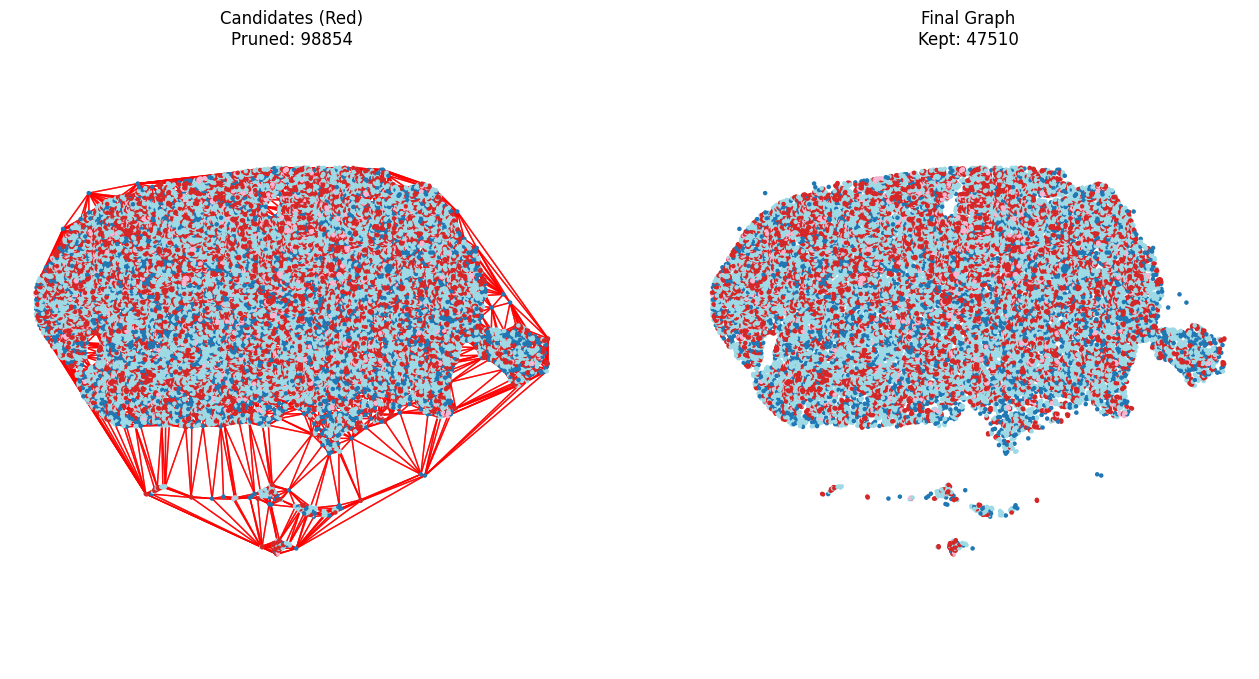

In [10]:
# 1. Compute neighbors (creates 'spatial_connectivities')
graph_utils.get_neighbors(adata, type="delaunay")

# 2. Visualize what WILL be pruned (Must run BEFORE pruning!)
# Visualize Distance Pruning
plot_pruned_connections(
    adata, 
    gmm_key="gmm_labels", 
    prune_by="distance",       # <--- Switch to distance mode
    distance_key="1_nn_distance",  # <--- Your distance column
    n_std=2.0,
    mode="comparison"
)
plt.show()

# 3. Now actually prune the graph
# graph_utils.prune_graph(adata, gmm_key="gmm_labels", distance_key="1_nn_distance", prune_by="distance")

# visualize which to prune (optional) - avoid in large datasets

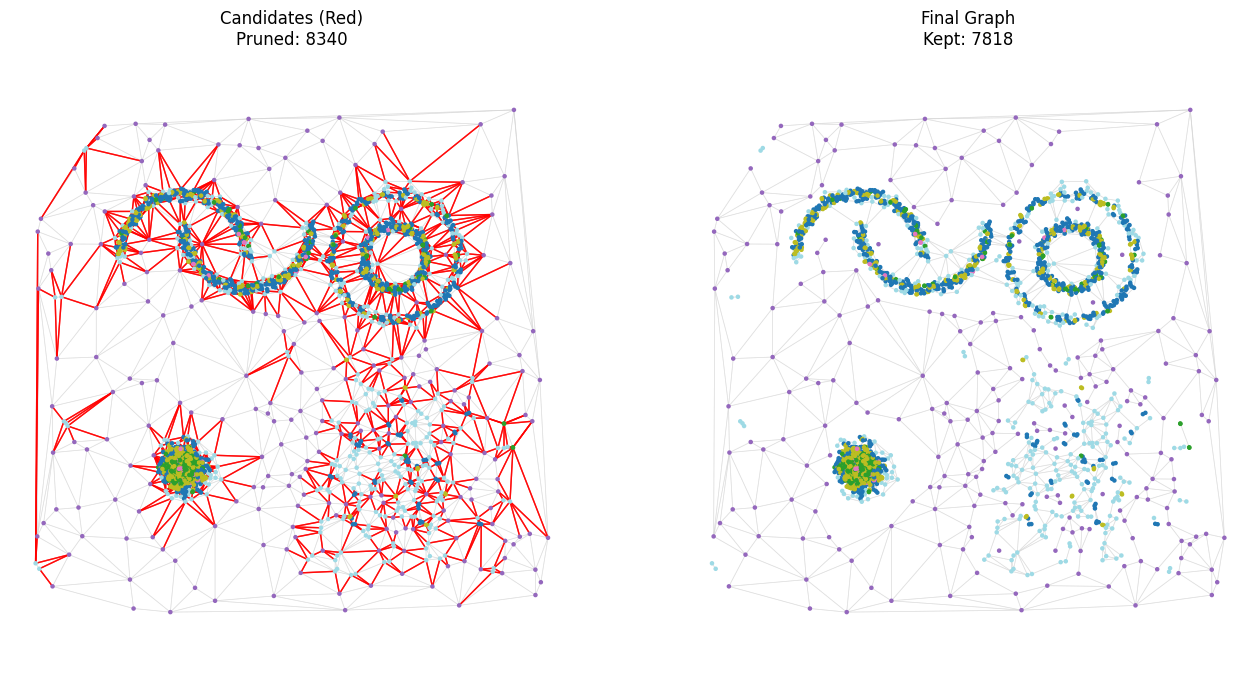

In [15]:
# 1. Compute neighbors (creates 'spatial_connectivities')
graph_utils.get_neighbors(adata, type="delaunay")

# 2. Visualize what WILL be pruned (Must run BEFORE pruning!)
# Visualize Distance Pruning
plot_pruned_connections(
    adata, 
    gmm_key="gmm_labels", 
    prune_by="label",       # <--- Switch to distance mode
    distance_key="1_nn_distance",  # <--- Your distance column
    n_std=4.0,
    mode="comparison"
)
plt.show()

# 3. Now actually prune the graph
# graph_utils.prune_graph(adata, gmm_key="gmm_labels", distance_key="1_nn_distance", prune_by="distance")

## Perform actual prune

In [11]:
graph_utils.prune_graph(adata, gmm_key="gmm_labels", distance_key="1_nn_distance", prune_by="distance")

Graph pruned by 'distance'. stored in 'pruned_spatial_connectivities'.


In [12]:
clustering.watershed_by_descent(adata, distances_key="1_nn_distance", spatial_connectivity_key="pruned_spatial_connectivities")

array([ 1055,   903,  6663, ..., 10359, 10278, 10280],
      shape=(24406,), dtype=int32)

In [13]:
plotting.assign_colors(sdata, "watershed_by_descent")

In [14]:

adata.obs["watershed_by_descent"].nunique()

10361

# Compare different algorithms

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


Saved plot to niches.png


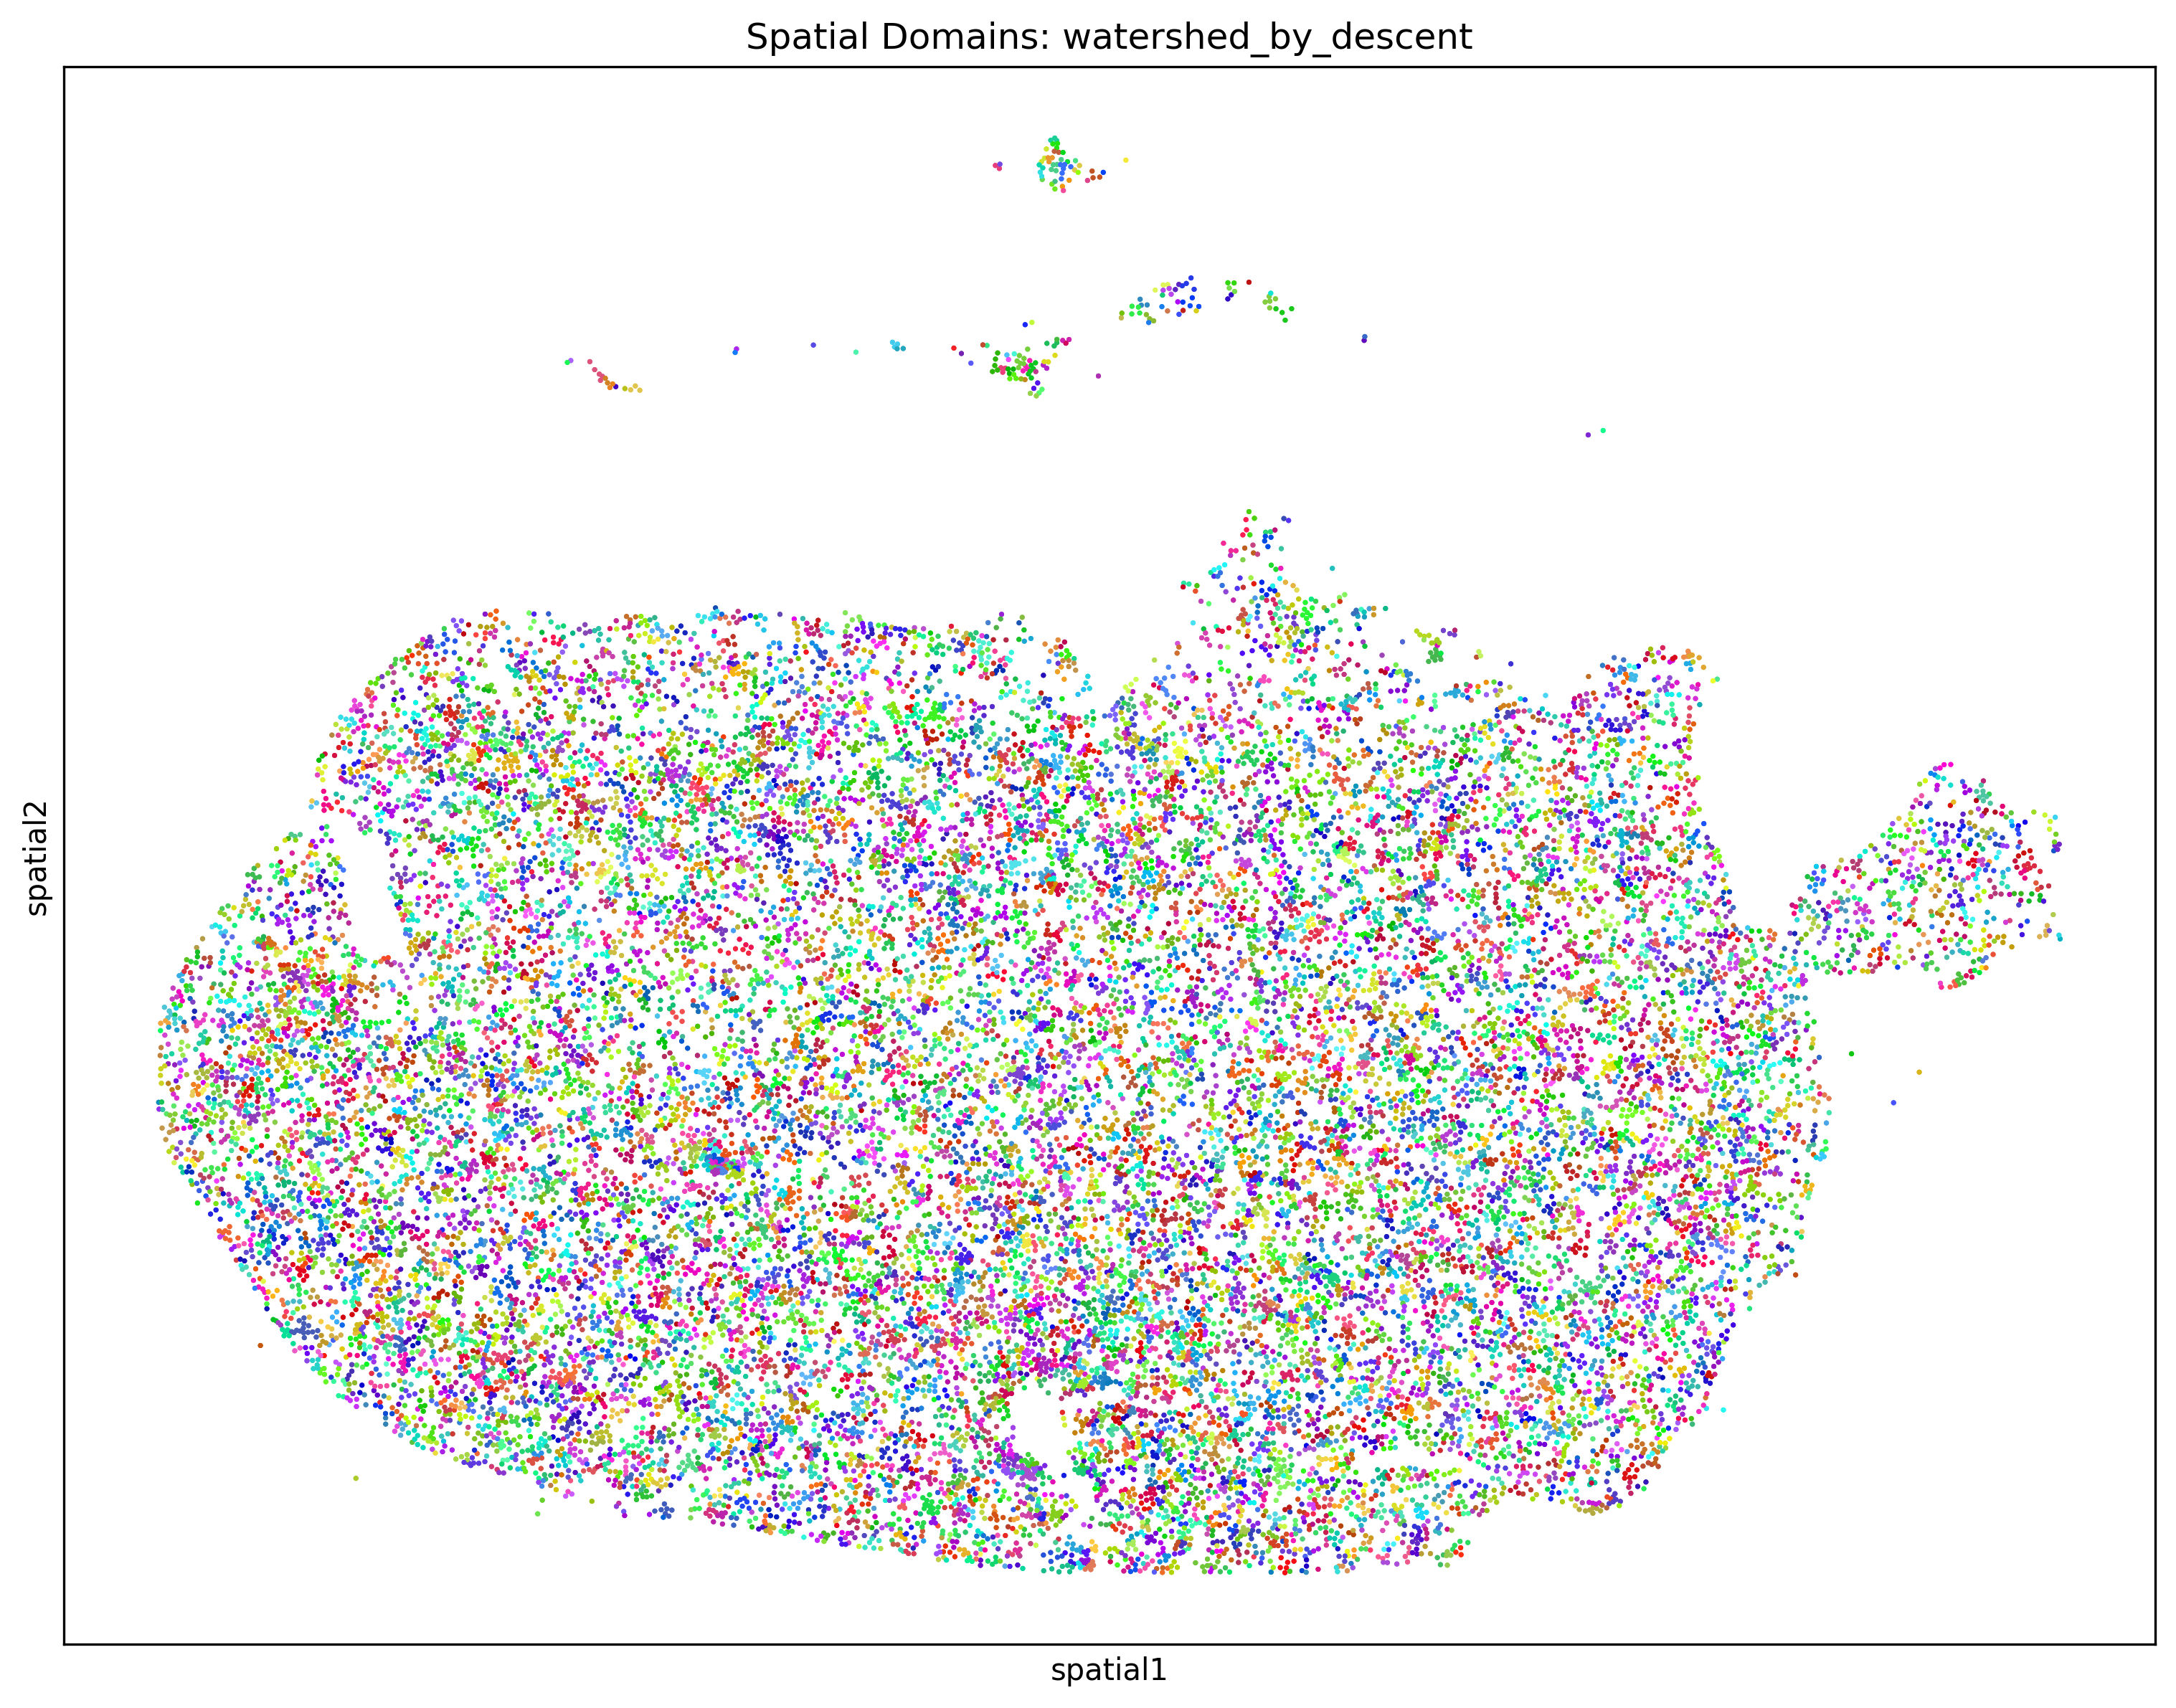

In [15]:
plotting.plot_niches(sdata, niche_key="watershed_by_descent", size=2, output_path="niches.png")

In [16]:
adata.obs["watershed_by_descent"].astype("category")

0         1055
1          903
2         6663
3          497
4          497
         ...  
24401    10360
24402    10361
24403    10359
24404    10278
24405    10280
Name: watershed_by_descent, Length: 24406, dtype: category
Categories (10361, int32): [1, 2, 3, 4, ..., 10358, 10359, 10360, 10361]

### Benchmarking
1. Benchmark using Ligand-Receptor-Co Localization

### Find Ligand-Receptor Pairs that are in our datasets
- Use LIANA - Consensus based => 16+ databases incl. CellChat, NicheNet, ..)
- https://saezlab.github.io/liana/
1. Load LIANA database
2. loop through all datasets in the folder and find the matching pairs


In [33]:
!python scripts/find_liana_pairs.py

/home/ktang/anaconda3/envs/single_cell_p311/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
Loading LIANA databases...
Human DB loaded: 4624 interactions (Format: LGALS9)
Mouse DB loaded: 3989 interactions (Format: Dll1)

Scanning 8 folders in '../single_cell/data'...

Skipping unused: No gene panel found.
Skipping zarr_outputs_no_images: No gene panel found.
--------------------------------------------------------------------------------
SUMMARY OF VIABLE INTERACTIONS
--------------------------------------------------------------------------------
                                                          Dataset Species  Viable_LR_Pairs
H_Bone_Xenium_V1_hBoneMarrow_acute_lymphoid_leukemia_section_outs   Human               64
       M_Bone_Xenium_V1_mFemur_formic_acid_24hrdecal_sec

We find that different datasets have different number of existing LR pairs. 
For experimentation, let's pick VCAN and EGFR from the human

In [26]:
!python scripts/plot_ligand_receptor.py --root ../single_cell/data/ --ligand VCAN --receptor EGFR --output figures/ 


Processing: unused...
Skipping unused: 'cell_feature_matrix.h5' not found.

Processing: H_Brain_Xenium_V1_FFPE_Human_Brain_Healthy_With_Addon_outs (1)...
/home/ktang/Adaptive-Niche/scripts/plot_ligand_receptor.py:69: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[['x', 'y']] = df_locs.loc[common, ['x_centroid', 'y_centroid']]
Saved: figures/H_Brain_Xenium_V1_FFPE_Human_Brain_Healthy_With_Addon_outs (1)_VCAN_EGFR_abundance.png

Processing: M_Brain_Xenium_V1_FF_Mouse_Brain_MultiSection_1_outs...
/home/ktang/Adaptive-Niche/scripts/plot_ligand_receptor.py:69: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[['x', 'y']] = df_locs.loc[common, ['x_centroid', 'y_centroid']]
Skipping M_Brain_Xenium_V1_FF_Mouse_Brain_MultiSection_1_outs: Genes missing.

Processing: M_Colon_Xenium_V1_mouse_Colon_FF_outs...
/home/ktang/Adaptive-Niche/scripts/plot_ligand_receptor.py:69:

# Let's apply this to our niches and calculate a score
We start by only measuring VCAN and EGFR Interaction score -> In the future, we can
- (Single)-Interaction-Score = Sum(Expr_R) * Sum(Expr_L)
- (Future: (Multi_LR)-Interaction-Score = Sum_i(Sum(Expr_Ri) * Sum(Expr_Li)))

In [29]:
import pandas as pd
import numpy as np
import squidpy as sq
import matplotlib.pyplot as plt
import scipy.sparse as sp

def calculate_niche_interaction(adata, ligand, receptor, niche_key="watershed_by_descent"):
    """
    Calculates an interaction potential score for a specific Ligand-Receptor pair
    per niche.
    
    Logic: 
    Score_niche = Mean_Expression_Ligand(niche) * Mean_Expression_Receptor(niche)
    
    This captures paracrine signaling (L and R present in the same neighborhood, 
    even if on different cells).
    """
    
    # 1. Check if genes exist
    if ligand not in adata.var_names:
        raise ValueError(f"Ligand '{ligand}' not found in adata.var_names")
    if receptor not in adata.var_names:
        raise ValueError(f"Receptor '{receptor}' not found in adata.var_names")
        
    print(f"Calculating interaction potential for {ligand} - {receptor}...")

    # 2. Extract expression data (handle sparse or dense)
    # We use the main .X layer. Ensure this is normalized/log-transformed data.
    if sp.issparse(adata.X):
        l_expr = adata[:, ligand].X.toarray().flatten()
        r_expr = adata[:, receptor].X.toarray().flatten()
    else:
        l_expr = adata[:, ligand].X.flatten()
        r_expr = adata[:, receptor].X.flatten()

    # 3. Create a temporary DataFrame
    # Ensure niche key is categorical for proper grouping
    if niche_key not in adata.obs:
         raise ValueError(f"Key '{niche_key}' not found in adata.obs")
         
    niches = adata.obs[niche_key].values
    
    df = pd.DataFrame({
        "Niche": niches,
        "L": l_expr,
        "R": r_expr
    })

    # 4. Group by Niche and calculate Mean Expression
    # We ignore Niche '0' if it represents background/outliers, 
    # but here we calculate for all.
    niche_stats = df.groupby("Niche", observed=True)[["L", "R"]].mean()
    
    # 5. Calculate Interaction Score: Mean(L) * Mean(R)
    niche_stats["interaction_score"] = niche_stats["L"] * niche_stats["R"]
    
    # 6. Map the score back to the AnnData object
    score_key = f"score_{ligand}_{receptor}"
    
    # Map values. Niches not present in the stats (if any) get NaN
    adata.obs[score_key] = adata.obs[niche_key].map(niche_stats["interaction_score"])
    
    # Fill NaNs with 0 (e.g. if a niche had no cells or was filtered out)
    adata.obs[score_key] = adata.obs[score_key].fillna(0)
    
    print(f"Score stored in adata.obs['{score_key}']")
    print(f"Max interaction score: {adata.obs[score_key].max():.4f}")
    
    return score_key

def plot_interaction_heatmap(adata, score_key, title=None, size=1, cmap="magma"):
    """
    Plots the spatial distribution of the interaction score.
    """
    if title is None:
        title = f"Interaction Potential: {score_key.replace('score_', '')}"
        
    # We use squidpy spatial scatter, coloring by the continuous score
    sq.pl.spatial_scatter(
        adata,
        color=score_key,
        size=size,
        title=title,
        cmap=cmap,
        shape=None,
        figsize=(10, 8),
        colorbar=True  # FIXED: changed from 'color_bar' to 'colorbar'
    )

Calculating interaction potential for VCAN - EGFR...
Score stored in adata.obs['score_VCAN_EGFR']
Max interaction score: 26.0000


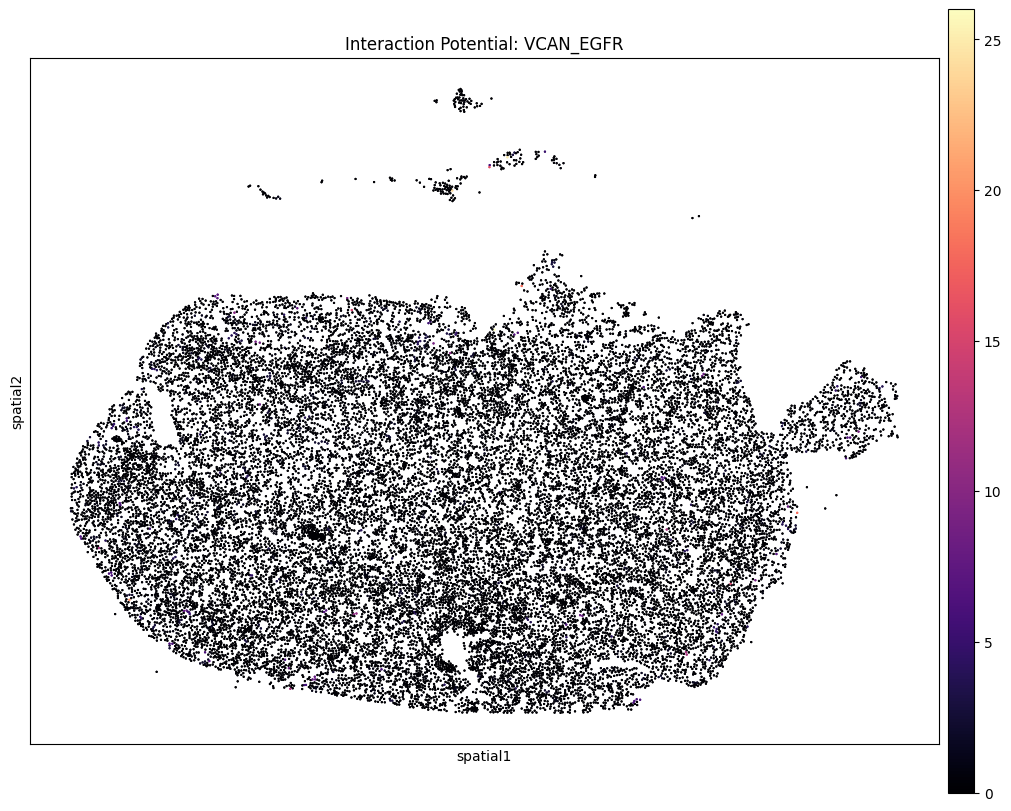

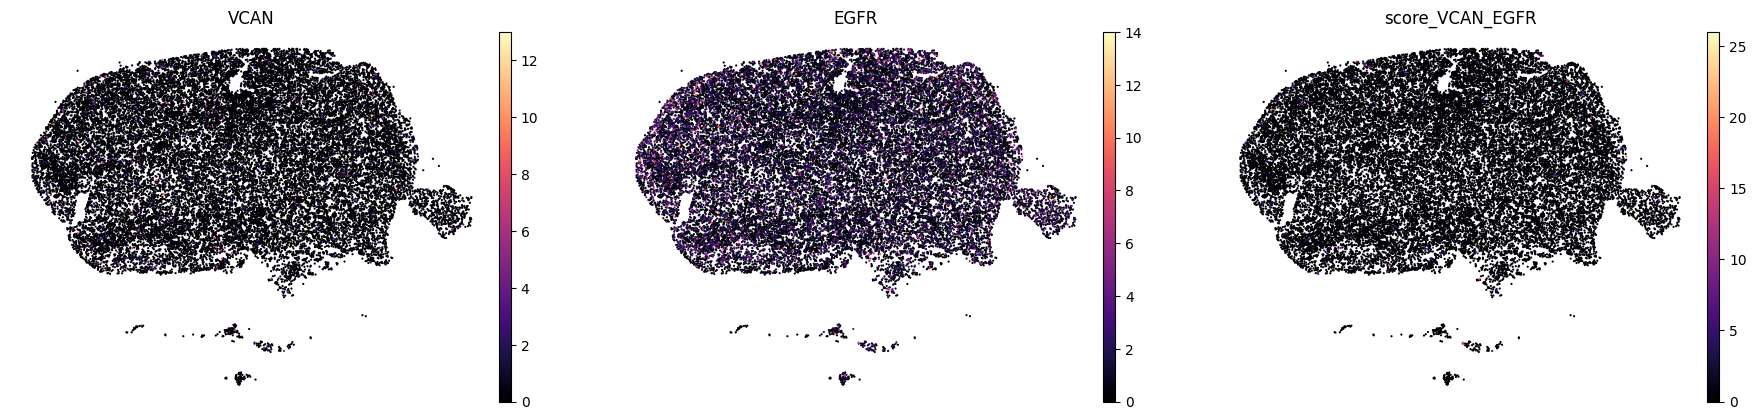

In [31]:
# 1. Calculate the score
# This adds 'score_VCAN_EGFR' to adata.obs
score_col = calculate_niche_interaction(
    adata, 
    ligand="VCAN", 
    receptor="EGFR", 
    niche_key="watershed_by_descent"
)

# 2. Visualize as a Spatial Heatmap
# 'magma' or 'inferno' are good cmaps for intensity scores
plot_interaction_heatmap(
    adata, 
    score_key=score_col, 
    size=1.5,
    cmap="magma"
)

import scanpy as sc

sc.pl.embedding(
    adata, 
    basis="spatial", 
    color=["VCAN", "EGFR", score_col], 
    size=10,       # Scanpy uses larger size integers than Squidpy
    cmap="magma", 
    ncols=3,
    frameon=False
)

In [32]:
adata.obs['score_VCAN_EGFR']

0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
24401    0.0
24402    0.0
24403    0.0
24404    0.0
24405    0.5
Name: score_VCAN_EGFR, Length: 24406, dtype: float32

### Now let's use all available pair

In [ ]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import squidpy as sq
import matplotlib.pyplot as plt


def _get_expr_matrix_dense(adata, genes, layer=None, dtype=np.float32):
    """
    Returns X (n_cells x n_genes) dense matrix for the requested genes.
    """
    genes = list(genes)
    missing = [g for g in genes if g not in adata.var_names]
    if missing:
        raise ValueError(f"Missing genes in adata.var_names: {missing[:10]}{' ...' if len(missing)>10 else ''}")

    X = adata[:, genes].layers[layer] if layer is not None else adata[:, genes].X
    if sp.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=dtype)
    return X, genes

def compute_niche_scores_all_pairs(
    adata,
    pairs_df,
    niche_key="watershed_by_descent",
    layer=None,
    drop_niche_values=None,   # e.g. [0] if you have background label
    return_cell_scores=False, # if True, maps overall score back to adata.obs
):
    """
    For each niche: score(niche, pair) = mean(L|niche) * mean(R|niche)

    Returns
    -------
    niche_scores_df: rows=niche labels, cols=pair_id, values=interaction_score
    pair_summary:    Series indexed by pair_id, weighted mean across cells
    overall_score:   scalar = mean(pair_summary)  (one number for plotting as a horizontal line)
    niche_sizes:     Series indexed by niche labels
    """
    if niche_key not in adata.obs:
        raise ValueError(f"'{niche_key}' not found in adata.obs")

    pairs_df = pairs_df.copy()
    if not {"ligand", "receptor"}.issubset(pairs_df.columns):
        raise ValueError("pairs_df must have columns: ['ligand','receptor']")

    # make pair_id
    pairs_df["pair_id"] = pairs_df["ligand"].astype(str) + "__" + pairs_df["receptor"].astype(str)

    # unique genes once
    genes = pd.unique(pd.concat([pairs_df["ligand"], pairs_df["receptor"]], ignore_index=True))
    X, genes = _get_expr_matrix_dense(adata, genes, layer=layer)

    gene_to_col = {g: i for i, g in enumerate(genes)}

    # niche codes
    niches_raw = adata.obs[niche_key].to_numpy()
    if drop_niche_values is not None:
        keep_mask = ~pd.Series(niches_raw).isin(drop_niche_values).to_numpy()
    else:
        keep_mask = np.ones(len(niches_raw), dtype=bool)

    niches = niches_raw[keep_mask]
    Xk = X[keep_mask, :]

    cat = pd.Categorical(niches)
    codes = cat.codes  # 0..(n_niches-1)
    niche_labels = cat.categories

    # niche sizes
    counts = np.bincount(codes, minlength=len(niche_labels)).astype(np.float64)
    if counts.sum() == 0:
        raise ValueError("No cells left after drop_niche_values filtering.")

    # compute per-niche mean for each gene via bincount (fast)
    # means: (n_niches x n_genes)
    n_niches = len(niche_labels)
    n_genes = Xk.shape[1]
    means = np.zeros((n_niches, n_genes), dtype=np.float64)

    for gi in range(n_genes):
        sums = np.bincount(codes, weights=Xk[:, gi], minlength=n_niches).astype(np.float64)
        means[:, gi] = sums / np.maximum(counts, 1.0)

    # compute per-pair per-niche scores
    niche_scores = np.zeros((n_niches, len(pairs_df)), dtype=np.float64)
    for p, (L, R) in enumerate(zip(pairs_df["ligand"], pairs_df["receptor"])):
        li = gene_to_col[L]
        ri = gene_to_col[R]
        niche_scores[:, p] = means[:, li] * means[:, ri]

    niche_scores_df = pd.DataFrame(niche_scores, index=niche_labels, columns=pairs_df["pair_id"].to_list())
    niche_sizes = pd.Series(counts, index=niche_labels, name="n_cells")

    # Weighted mean across cells for each pair:
    # sum_niche(score_niche * niche_size) / total_cells
    weights = counts / counts.sum()
    pair_summary = pd.Series((niche_scores.T @ weights).astype(np.float64), index=niche_scores_df.columns, name="weighted_mean_cell")

    overall_score = float(pair_summary.mean())

    if return_cell_scores:
        # map an overall-per-niche score back to cells for visualization if you want
        overall_per_niche = niche_scores_df.mean(axis=1)  # average across pairs per niche
        adata.obs[f"lr_overall_{niche_key}"] = pd.Series(adata.obs[niche_key]).map(overall_per_niche).fillna(0.0).to_numpy()

    return niche_scores_df, pair_summary, overall_score, niche_sizes


def compute_knn_ego_scores_curve(
    adata,
    pairs_df,
    k_values=range(5, 21),
    layer=None,
    coord_type="generic",
    include_self=True,
    cell_agg="mean",          # "mean" or "median"
):
    """
    Per-cell KNN ego-niche score for each K:
      score_i(pair) = mean(L over neighbors of i) * mean(R over neighbors of i)

    Returns
    -------
    knn_scores_df: DataFrame with index=K and columns:
      - overall  (mean across pairs)
      - plus each pair_id column (aggregated across cells)
    """
    pairs_df = pairs_df.copy()
    if not {"ligand", "receptor"}.issubset(pairs_df.columns):
        raise ValueError("pairs_df must have columns: ['ligand','receptor']")
    pairs_df["pair_id"] = pairs_df["ligand"].astype(str) + "__" + pairs_df["receptor"].astype(str)

    # unique genes once
    genes = pd.unique(pd.concat([pairs_df["ligand"], pairs_df["receptor"]], ignore_index=True))
    X, genes = _get_expr_matrix_dense(adata, genes, layer=layer, dtype=np.float32)
    gene_to_col = {g: i for i, g in enumerate(genes)}

    n = adata.n_obs
    X = np.asarray(X, dtype=np.float32)  # (n x g)

    out_rows = []

    for K in k_values:
        # Build KNN graph; store under a key to avoid overwriting issues
        key = f"knn_{K}"
        sq.gr.spatial_neighbors(
            adata,
            coord_type=coord_type,
            n_neighs=int(K),
            delaunay=False,
            key_added=key
        )

        A_key = f"{key}_connectivities"
        if A_key in adata.obsp:
            A = adata.obsp[A_key].tocsr()
        else:
            # fallback if squidpy version doesn't use key_added naming
            A = adata.obsp["spatial_connectivities"].tocsr()

        if include_self:
            A = A + sp.eye(n, format="csr", dtype=A.dtype)

        deg = np.asarray(A.sum(axis=1)).ravel().astype(np.float32)
        deg = np.maximum(deg, 1.0)

        # neighbor mean expression for all requested genes at once
        neigh_sum = A @ X                       # (n x g)
        neigh_mean = neigh_sum / deg[:, None]   # (n x g)

        # aggregate per pair across cells
        pair_vals = {}
        for (L, R, pid) in zip(pairs_df["ligand"], pairs_df["receptor"], pairs_df["pair_id"]):
            li = gene_to_col[L]
            ri = gene_to_col[R]
            s = neigh_mean[:, li] * neigh_mean[:, ri]  # per-cell

            if cell_agg == "mean":
                pair_vals[pid] = float(np.mean(s))
            elif cell_agg == "median":
                pair_vals[pid] = float(np.median(s))
            else:
                raise ValueError("cell_agg must be 'mean' or 'median'")

        overall = float(np.mean(list(pair_vals.values()))) if pair_vals else np.nan

        row = {"K": int(K), "overall": overall}
        row.update(pair_vals)
        out_rows.append(row)

    knn_scores_df = pd.DataFrame(out_rows).set_index("K").sort_index()
    return knn_scores_df


def plot_knn_vs_method(knn_scores_df, method_score, title=None, ylabel="Overall LR interaction score"):
    """
    Plot overall score vs K with a horizontal line for your method.
    """
    Ks = knn_scores_df.index.to_numpy()
    y = knn_scores_df["overall"].to_numpy()

    plt.figure(figsize=(7, 4.5))
    plt.plot(Ks, y, marker="o")
    plt.axhline(method_score, linestyle="--", linewidth=2)

    plt.xlabel("K (KNN ego-niche)")
    plt.ylabel(ylabel)
    if title is None:
        title = "KNN ego-niche baseline vs adaptive method"
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [36]:
# --- Load LR pairs from your LIANA CSV ---
# Expected columns: ligand,receptor
pairs_path = "../single_cell/data/H_Brain_Xenium_V1_FFPE_Human_Brain_Healthy_With_Addon_outs (1)/valid_lr_pairs.csv"   # <-- change this path
pairs_df = pd.read_csv(pairs_path)

# Optional: ensure correct column names
pairs_df = pairs_df.rename(columns={c: c.strip().lower() for c in pairs_df.columns})
assert {"ligand", "receptor"}.issubset(pairs_df.columns)

# --- (A) Your method: niche scores from watershed_by_descent ---
niche_scores_df, pair_summary_ours, overall_ours, niche_sizes = compute_niche_scores_all_pairs(
    adata,
    pairs_df=pairs_df,
    niche_key="watershed_by_descent",
    layer=None,               # or e.g. "log1p" if you store expression in a layer
    drop_niche_values=None,   # or [0] if you have background niche label 0
    return_cell_scores=False
)

print("Your method overall score (mean across pairs, weighted across cells):", overall_ours)
display(pair_summary_ours.sort_values(ascending=False).head(10))  # top LR pairs under your method
display(niche_scores_df.head())  # per-niche per-pair scores (big table)

Your method overall score (mean across pairs, weighted across cells): 0.42310899615692216


NPTX1__NPTXR      10.901040
FGFR3__EPHA4       0.833752
BCAN__EGFR         0.671386
CNTN2__NRP1        0.313021
CCN2__FGFR2        0.259829
CCN2__EGFR         0.251171
PSEN1__NOTCH1      0.244086
ADAM17__NOTCH1     0.236576
DCN__EGFR          0.192653
PSEN1__NCSTN       0.169445
Name: weighted_mean_cell, dtype: float64

,HLA-DQA1__CD4,ANXA1__EGFR,APP__CD74,APP__NCSTN,THBS1__CD36,CD14__ITGB2,CD48__CD2,CDH1__EGFR,HLA-DMB__CD4,ADAM17__NOTCH1,...,SPON1__APP,PSEN1__NCSTN,TAC1__TACR1,PSEN1__NOTCH1,C3__ITGAM,C3__ITGAX,C3__NRP1,TGFB1__CAV1,NPTX1__NPTXR,S100A4__ERBB3
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,3.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,12.000000,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,2.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,90.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,...,0.0,0.888889,0.0,0.222222,0.0,0.0,0.666667,0.0,46.666667,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,3.000000,0.0,0.0,0.000000,0.0,1.000000,0.0


In [39]:
niche_scores_df

,HLA-DQA1__CD4,ANXA1__EGFR,APP__CD74,APP__NCSTN,THBS1__CD36,CD14__ITGB2,CD48__CD2,CDH1__EGFR,HLA-DMB__CD4,ADAM17__NOTCH1,...,SPON1__APP,PSEN1__NCSTN,TAC1__TACR1,PSEN1__NOTCH1,C3__ITGAM,C3__ITGAX,C3__NRP1,TGFB1__CAV1,NPTX1__NPTXR,S100A4__ERBB3
1,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,3.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000,0.000000,0.0
2,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000,12.000000,0.0
3,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,2.000000,0.0,0.000000,0.0,0.0,0.000000,0.000,90.000000,0.0
4,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.111111,...,0.0,0.888889,0.0,0.222222,0.0,0.0,0.666667,0.000,46.666667,0.0
5,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,3.000000,0.0,0.0,0.000000,0.000,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10357,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.125,14.000000,0.0
10358,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000,20.000000,0.0
10359,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.750000,0.0,0.000000,0.0,0.0,0.000000,0.000,10.500000,0.0
10360,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000,0.000000,0.0


,overall
K,
2,0.375317
3,0.372406
4,0.369545
5,0.368281
6,0.368499
7,0.366908
8,0.365250
9,0.364816
10,0.364246


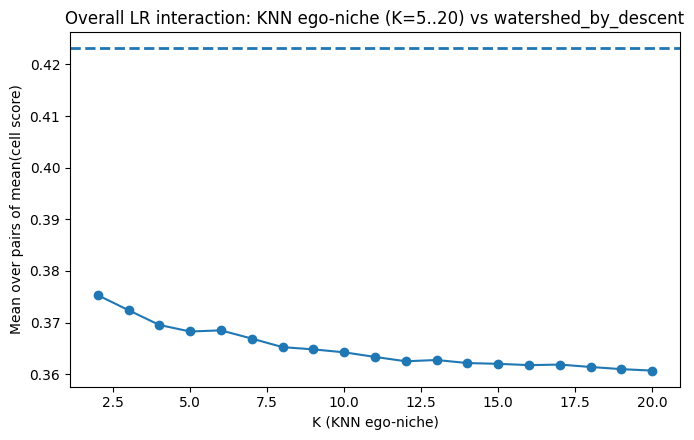

In [38]:
# --- (B) KNN ego-niche baseline: K = 5..20 ---
knn_scores_df = compute_knn_ego_scores_curve(
    adata,
    pairs_df=pairs_df,
    k_values=range(2, 21),
    layer=None,
    coord_type="generic",
    include_self=True,
    cell_agg="mean"   # try "median" if sparse / heavy-tailed
)

display(knn_scores_df[["overall"]])

# --- Plot: KNN curve + horizontal line for your method ---
plot_knn_vs_method(
    knn_scores_df,
    method_score=overall_ours,
    title="Overall LR interaction: KNN ego-niche (K=5..20) vs watershed_by_descent",
    ylabel="Mean over pairs of mean(cell score)"
)